# Hybrid Agentic Workflows using LangGraph - Finance Domain

## Environment Setup and Imports

This section handles installing necessary libraries and importing modules required for building the agentic workflow. It also sets up API keys for external services and initializes the Language Model.

In [ ]:
!pip install -q langgraph langchain langchain-google-genai google-search-results

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.8 MB/s eta 0:00:00


In [ ]:
import re
import os
import random # For simulating tool outputs
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from serpapi import GoogleSearch
from langchain_core.tools import StructuredTool, tool
from pydantic import BaseModel, Field, ValidationError
import json

In [ ]:
# Install graphviz system package for diagram visualization
!sudo apt-get update
!sudo apt-get install -y graphviz

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,644 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/univers

In [ ]:
from google.colab import userdata

os.environ['GOOGLE_API_KEY']=userdata.get('GOOGLE_API_KEY')
os.environ['SERP_API_KEY']=userdata.get('SERP_API_KEY')

In [ ]:
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

## 3) Finance Domain Assignment

This section utilizes the previously defined financial operations workflow. It categorizes financial queries into risk analysis, investment advisory, or compliance review and routes them to specialized agents.

In [ ]:
import json

# Define the state for the Finance workflow, for Loan Risk Assessment
class FinanceState(TypedDict):
  query: str
  # Applicant Input Fields
  applicant_name: str | None
  loan_amount: float | None
  employment_type: str | None
  credit_score: int | None
  debt_to_income_ratio: float | None # for DTI
  has_salary_slips: bool | None # for document check
  has_bank_statements: bool | None # for document check
  # Applicant Analysis & Verification Fields
  income_stability: Literal["low", "medium", "high"] | None
  missing_documents: list[str] | None
  spending_patterns_assessment: str | None # New: for spending patterns
  financial_behavior_assessment: str | None # New: for financial behavior
  fraud_risk_score: int | None # e.g., 0-100
  kyc_verified: bool | None
  employment_verified: bool | None
  # Decision Fields
  loan_decision: Literal["approved", "rejected", "escalated", "clarification_needed", "fast_track"] | None
  approval_rationale: str | None
  risk_summary: str | None # New: for risk summary
  recommended_loan_amount: float | None
  suggested_interest_slab: str | None # e.g., 'A', 'B', 'C'
  notify_applicant: str | None # Message to send to applicant
  route: str # This will be the next node determined by decision function
  output: str # Final consolidated output for the user

# Define Pydantic schema for the structured input of a loan application
class LoanApplicationInput(BaseModel):
  applicant_name: str = Field(description="Full name of the loan applicant.")
  loan_amount: float = Field(description="The amount of loan requested by the applicant.")
  employment_type: Literal["employed", "self-employed", "unemployed", "student", "retired"] = Field(description="Type of employment of the applicant.")
  credit_score: int = Field(description="Applicant's credit score.", ge=300, le=850)
  has_salary_slips: bool = Field(description="True if salary slips are provided, False otherwise.")
  has_bank_statements: bool = Field(description="True if bank statements are provided, False otherwise.")
  query: str = Field(description="Any additional context or query from the applicant.")

# Define Pydantic schema for the structured output of the initial applicant analysis
class ApplicantAnalysisOutput(BaseModel):
  income_stability: Literal["low", "medium", "high"] = Field(description="Assessment of the applicant's income stability.")
  missing_documents: list[str] = Field(description="List of any documents missing from the application.")
  debt_to_income_ratio: float = Field(description="Calculated debt-to-income ratio.")
  spending_patterns_assessment: str = Field(description="Assessment of spending patterns (e.g., 'Conservative', 'Moderate', 'Aggressive', 'Limited data').")
  financial_behavior_assessment: str = Field(description="Assessment of overall financial behavior (e.g., 'Responsible', 'Average', 'Needs improvement', 'Limited data').")

# Define Pydantic schema for the structured output of the verification layer
class VerificationOutput(BaseModel):
  fraud_risk_score: int = Field(description="Score indicating fraud risk (0-100, higher is riskier).")
  kyc_verified: bool = Field(description="True if KYC (Know Your Customer) checks are successful, False otherwise.")
  employment_verified: bool = Field(description="True if employment is successfully verified, False otherwise.")

# Define Pydantic schema for the final loan decision output
class LoanDecisionOutput(BaseModel):
  loan_decision: Literal["approved", "rejected", "escalated", "clarification_needed", "fast_track"] = Field(description="The final decision on the loan application.")
  approval_rationale: str = Field(description="Detailed reason for the loan decision.")
  risk_summary: str = Field(description="A summary of the overall risk assessment for the applicant.")
  recommended_loan_amount: float = Field(description="The recommended loan amount, potentially different from requested.")
  suggested_interest_slab: str = Field(description="The suggested interest rate slab for the loan.")
  notify_applicant: str = Field(description="A message to be sent to the applicant regarding the decision.")

## Mock Backend System Tools for Finance

These are simulated tools that interact with various backend systems relevant to finance operations. These tools allow the specialized agent nodes to retrieve or update information as needed.

In [ ]:
# --- Mock Financial Tools for Loan Processing --- #
# These tools simulate interactions with various financial systems.

class CheckCreditScoreInput(BaseModel):
  applicant_name: str = Field(description="The name of the applicant.")

@tool("check_credit_score_tool", args_schema=CheckCreditScoreInput)
def check_credit_score_tool(applicant_name: str) -> str:
  """Simulates checking an applicant's credit score based on their name."""
  # In a real system, this would query a credit bureau.
  scores = {"Alice Smith": 720, "Bob Johnson": 650, "Charlie Brown": 580}
  score = scores.get(applicant_name, random.randint(500, 800))
  return f"Credit score for {applicant_name}: {score}"

class VerifyEmploymentInput(BaseModel):
  applicant_name: str = Field(description="The name of the applicant.")
  employment_type: str = Field(description="The reported employment type.")

@tool("verify_employment_tool", args_schema=VerifyEmploymentInput)
def verify_employment_tool(applicant_name: str, employment_type: str) -> str:
  """Simulates verifying an applicant's employment status."""
  # In a real system, this would involve contacting employers or databases.
  if employment_type in ["employed", "self-employed"] and random.random() > 0.1:
      return f"Employment for {applicant_name} ({employment_type}) successfully verified."
  else:
      return f"Employment for {applicant_name} ({employment_type}) could not be verified at this time."

class AssessFraudRiskInput(BaseModel):
  applicant_name: str = Field(description="The name of the applicant.")
  loan_amount: float = Field(description="The requested loan amount.")

@tool("assess_fraud_risk_tool", args_schema=AssessFraudRiskInput)
def assess_fraud_risk_tool(applicant_name: str, loan_amount: float) -> str:
  """Simulates assessing the fraud risk for a loan application."""
  # This would involve looking for inconsistencies, suspicious patterns, etc.
  risk_score = random.randint(0, 100) # 0-20 low, 21-50 medium, 51-100 high
  if "suspect" in applicant_name.lower() or loan_amount > 100000 and random.random() > 0.5:
      risk_score = random.randint(60, 95)
  return f"Fraud risk score for {applicant_name}: {risk_score}."

class CalculateDebtToIncomeInput(BaseModel):
  applicant_name: str = Field(description="The name of the applicant.")
  salary_slips_provided: bool = Field(description="True if salary slips are provided.")
  bank_statements_provided: bool = Field(description="True if bank statements are provided.")

@tool("calculate_debt_to_income_tool", args_schema=CalculateDebtToIncomeInput)
def calculate_debt_to_income_tool(applicant_name: str, salary_slips_provided: bool, bank_statements_provided: bool) -> str:
  """Simulates calculating debt-to-income ratio based on provided documents."""
  if salary_slips_provided and bank_statements_provided:
      dti = round(random.uniform(0.15, 0.60), 2) * 100 # percentage
      return f"Calculated Debt-to-Income (DTI) for {applicant_name}: {dti:.2f}%."
  else:
      return f"Cannot calculate Debt-to-Income (DTI) for {applicant_name} due to insufficient documentation."

class VerifyKYCInput(BaseModel):
  applicant_name: str = Field(description="The name of the applicant.")

@tool("verify_kyc_tool", args_schema=VerifyKYCInput)
def verify_kyc_tool(applicant_name: str) -> str:
  """Simulates KYC (Know Your Customer) verification."""
  if "test" in applicant_name.lower() or random.random() > 0.05: # High success rate for demo
      return f"KYC for {applicant_name} successfully verified."
  else:
      return f"KYC for {applicant_name} failed verification."


# List of all finance tools
finance_tools = [
    check_credit_score_tool,
    verify_employment_tool,
    assess_fraud_risk_tool,
    calculate_debt_to_income_tool,
    verify_kyc_tool
]

## Finance Agent Nodes

This section defines the individual nodes that comprise the finance agentic workflow, including the router, and specialized handler agents.

In [ ]:
import json

# Define the Loan Application Analysis Node
# This node analyzes the structured loan application input.
def loan_application_analyzer_node(state: FinanceState):
  raw_input = state['query']
  application_input = None
  try:
      application_input = LoanApplicationInput.model_validate_json(raw_input)
  except ValidationError as e:
      # If input parsing fails, return an error output
      return {"output": f"Error: Invalid loan application input format: {e}", "loan_decision": "escalated"}
  except json.JSONDecodeError as e:
      # If JSON decoding fails, return an error output
      return {"output": f"Error: Invalid JSON in loan application input: {e}", "loan_decision": "escalated"}

  # Initialize a dictionary with parsed applicant input, to be used as a base for the state update
  # These fields are directly from the user's input and should always be populated if parsing succeeds.
  updated_state_from_input = {
      "applicant_name": application_input.applicant_name,
      "loan_amount": application_input.loan_amount,
      "employment_type": application_input.employment_type,
      "credit_score": application_input.credit_score,
      "has_salary_slips": application_input.has_salary_slips,
      "has_bank_statements": application_input.has_bank_statements,
      "query": application_input.query, # Keep the original query in the state
  }

  structured_llm = llm.with_structured_output(ApplicantAnalysisOutput)

  prompt_content = f"""
  You are a Loan Application Analyst. Your task is to process a structured loan application, assess income stability, identify any missing documents, evaluate spending patterns, and assess financial behavior. The applicant's details are:
  Applicant Name: {application_input.applicant_name}
  Loan Amount Requested: {application_input.loan_amount}
  Employment Type: {application_input.employment_type}
  Credit Score: {application_input.credit_score}
  Salary Slips Provided: {application_input.has_salary_slips}
  Bank Statements Provided: {application_input.has_bank_statements}
  Additional Query: {application_input.query}

  Based on this information, assess the applicant's income stability (low, medium, high), detect any clearly missing documents (e.g., if salary slips are marked as False but required for income stability), and calculate a hypothetical Debt-to-Income (DTI) ratio. Use the `calculate_debt_to_income_tool` if both salary slips and bank statements are provided to get a DTI. If not, state that DTI cannot be calculated.

  For 'spending_patterns_assessment' and 'financial_behavior_assessment', provide a general assessment or state 'Limited data' if detailed information is not available from the current inputs.
  """

  # Invoke the structured LLM with the prompt
  try:
      parsed_output = structured_llm.invoke(prompt_content)
      # Merge parsed_output fields into the updated_state_from_input
      updated_state_from_input.update({
          "income_stability": parsed_output.income_stability,
          "missing_documents": parsed_output.missing_documents,
          "debt_to_income_ratio": parsed_output.debt_to_income_ratio,
          "spending_patterns_assessment": parsed_output.spending_patterns_assessment,
          "financial_behavior_assessment": parsed_output.financial_behavior_assessment,
      })
      return updated_state_from_input
  except Exception as e:
      print(f"Error invoking structured LLM in loan_application_analyzer_node: {e}")
      # If LLM fails, propagate the error but keep the basic applicant info
      updated_state_from_input["output"] = f"Error processing LLM analysis for applicant {application_input.applicant_name}: {e}"
      # Set LLM-derived fields to default/None if the LLM failed, or a placeholder for routing
      updated_state_from_input["income_stability"] = "unknown" # Or None
      # Make sure missing_documents is a list to avoid type errors in later nodes
      updated_state_from_input["missing_documents"] = ["LLM analysis for spending/behavior failed"]
      updated_state_from_input["debt_to_income_ratio"] = None
      updated_state_from_input["spending_patterns_assessment"] = "LLM analysis failed"
      updated_state_from_input["financial_behavior_assessment"] = "LLM analysis failed"
      updated_state_from_input["loan_decision"] = "clarification_needed" # To force a specific route
      updated_state_from_input["approval_rationale"] = updated_state_from_input["output"]
      updated_state_from_input["notify_applicant"] = f"Dear {application_input.applicant_name}, there was an issue processing some of your application details. Please contact support or provide more information."

      return updated_state_from_input

In [ ]:
# Define the Verification Node
# This node uses mock tools to perform various checks.
def verification_node(state: FinanceState):
  applicant_name = state.get('applicant_name')
  loan_amount = state.get('loan_amount')
  employment_type = state.get('employment_type')
  has_salary_slips = state.get('has_salary_slips')
  has_bank_statements = state.get('has_bank_statements')

  # Check for essential input values, which should have been populated by loan_application_analyzer_node
  if any(val is None for val in [applicant_name, loan_amount, employment_type, has_salary_slips, has_bank_statements]):
      print("Verification Node: Essential applicant details are None. Rerouting for clarification.")
      # This indicates a failure in previous node or initial state, route for clarification
      return {
          "loan_decision": "clarification_needed",
          "approval_rationale": "Missing essential applicant details for verification.",
          "notify_applicant": f"Dear {applicant_name if applicant_name else 'applicant'}, your application could not be fully verified due to missing essential details. Please contact support.",
          "output": "Verification failed due to missing essential applicant details."
      }

  llm_with_tools = llm.bind_tools(finance_tools)
  structured_llm = llm_with_tools.with_structured_output(VerificationOutput)

  prompt_content = f"""
  You are a Financial Verification Agent. Perform the following checks for the applicant '{applicant_name}' with a requested loan amount of {loan_amount}:
  1. **Credit Score**: Use `check_credit_score_tool` for {applicant_name}.
  2. **Employment Verification**: Use `verify_employment_tool` for {applicant_name} with employment type '{employment_type}'.
  3. **Fraud Risk Assessment**: Use `assess_fraud_risk_tool` for {applicant_name} and loan amount {loan_amount}.
  4. **KYC Verification**: Use `verify_kyc_tool` for {applicant_name}.
  5. **Debt-to-Income Calculation**: Use `calculate_debt_to_income_tool` if salary slips and bank statements are provided (currently salary_slips={has_salary_slips}, bank_statements={has_bank_statements}).

  Based on the outputs of these tools, summarize the verification results and determine a final fraud risk score, KYC status, and employment verification status. All values should be inferred from tool outputs where possible.

  Generate a structured JSON output strictly conforming to the `VerificationOutput` Pydantic schema. Provide realistic scores and boolean statuses based on the tool outputs and input values.
  """

  try:
      parsed_output = structured_llm.invoke(prompt_content)
      # Merge parsed output with existing state
      updated_state = {
          **state, # Carry forward all previous state
          "fraud_risk_score": parsed_output.fraud_risk_score,
          "kyc_verified": parsed_output.kyc_verified,
          "employment_verified": parsed_output.employment_verified,
      }
      return updated_state
  except Exception as e:
      print(f"Error invoking structured LLM in verification_node: {e}")
      # If LLM fails, propagate the error but keep the basic applicant info
      return {
          **state, # Carry forward all previous state
          "output": f"Error processing LLM verification for applicant {applicant_name}: {e}",
          "loan_decision": "clarification_needed",
          "approval_rationale": f"Verification failed due to LLM processing error: {e}",
          "notify_applicant": f"Dear {applicant_name}, there was an issue during the verification process. Please contact support.",
          "fraud_risk_score": None, # Reset or set to default
          "kyc_verified": False,
          "employment_verified": False,
      }

In [ ]:
# --- Specialized Routing Agents --- #
# These nodes produce an initial LoanDecisionOutput based on their specific focus.

# Fast-track Approval Agent
def fast_track_approval_node(state: FinanceState):
  return {
      "loan_decision": "fast_track",
      "approval_rationale": f"Applicant {state['applicant_name']} qualifies for fast-track approval due to excellent credit score ({state['credit_score']}) and low fraud risk ({state['fraud_risk_score']}).",
      "recommended_loan_amount": state['loan_amount'],
      "suggested_interest_slab": "A",
      "notify_applicant": f"Congratulations {state['applicant_name']}! Your loan application for {state['loan_amount']}$ has been fast-track approved with a competitive interest rate. We will contact you shortly to finalize the details.",
      "output": f"Fast-track approval for {state['applicant_name']}."
  }

# Fraud Investigation Agent
def fraud_investigation_node(state: FinanceState):
  return {
      "loan_decision": "escalated",
      "approval_rationale": f"Loan application for {state['applicant_name']} escalated to fraud investigation due to high fraud risk score ({state['fraud_risk_score']}).",
      "recommended_loan_amount": 0.0, # Not applicable yet
      "suggested_interest_slab": "N/A",
      "notify_applicant": f"Dear {state['applicant_name']}, your loan application requires further review by our fraud investigation team. We will be in touch shortly.",
      "output": f"Escalated to fraud investigation for {state['applicant_name']}."
  }

# Clarification Agent
def clarification_agent_node(state: FinanceState):
  missing_docs = ", ".join(state['missing_documents']) if state['missing_documents'] else "further information"
  return {
      "loan_decision": "clarification_needed",
      "approval_rationale": f"Loan application for {state['applicant_name']} requires clarification due to missing documents: {missing_docs}.",
      "recommended_loan_amount": 0.0, # Not applicable yet
      "suggested_interest_slab": "N/A",
      "notify_applicant": f"Dear {state['applicant_name']}, your loan application requires {missing_docs}. Please provide these to proceed.",
      "output": f"Clarification needed for {state['applicant_name']}."
  }

# Manual Review Agent
def manual_review_node(state: FinanceState):
  return {
      "loan_decision": "escalated",
      "approval_rationale": f"Loan application for {state['applicant_name']} routed to manual review due to medium risk profile (Credit Score: {state['credit_score']}, DTI: {state['debt_to_income_ratio']}).",
      "recommended_loan_amount": state['loan_amount'],
      "suggested_interest_slab": "B", # Placeholder
      "notify_applicant": f"Dear {state['applicant_name']}, your loan application is currently under manual review. We will inform you of our decision soon.",
      "output": f"Manual review for {state['applicant_name']}."
  }

# Rejection Recommendation Agent
def rejection_recommendation_node(state: FinanceState):
  rationale = f"Applicant {state['applicant_name']} is recommended for rejection due to high debt-to-income ratio ({state['debt_to_income_ratio']}) and/or low credit score ({state['credit_score']})."
  return {
      "loan_decision": "rejected",
      "approval_rationale": rationale,
      "recommended_loan_amount": 0.0, # Not applicable
      "suggested_interest_slab": "N/A",
      "notify_applicant": f"Dear {state['applicant_name']}, we regret to inform you that your loan application has been rejected. This decision was based on your financial profile, including a high debt-to-income ratio. Please review our financial wellness resources for assistance.",
      "output": f"Rejection recommended for {state['applicant_name']}."
  }

In [ ]:
# Define the Decision Orchestrator Node
# This node finalizes the loan decision and generates comprehensive output.
def decision_orchestrator_node(state: FinanceState):
  # This node typically gets called after a specific routing agent has set an initial decision.
  # It can refine the decision or just format the final output.

  final_decision = state.get('loan_decision', 'unknown')
  rationale = state.get('approval_rationale', 'No specific rationale provided.')
  recommended_amount = state.get('recommended_loan_amount', 0.0)
  interest_slab = state.get('suggested_interest_slab', 'N/A')
  notification = state.get('notify_applicant', 'Your application is being processed.')

  # Generate risk summary
  risk_summary_text = f"Credit Score: {state.get('credit_score', 'N/A')}. Fraud Risk Score: {state.get('fraud_risk_score', 'N/A')}. DTI: {state.get('debt_to_income_ratio', 'N/A')}%. Income Stability: {state.get('income_stability', 'N/A')}."
  if state.get('missing_documents'):
      risk_summary_text += f" Missing Documents: {', '.join(state['missing_documents'])}."

  output_summary = f"""
  --- Loan Decision Summary for {state.get('applicant_name', 'Applicant')}: ---
  Decision: {final_decision.upper()}
  Rationale: {rationale}
  Risk Summary: {risk_summary_text}
  Recommended Loan Amount: ${recommended_amount:,.2f}
  Suggested Interest Slab: {interest_slab}
  Applicant Notification: {notification}
  """

  return {
      "output": output_summary,
      "loan_decision": final_decision,
      "approval_rationale": rationale,
      "risk_summary": risk_summary_text,
      "recommended_loan_amount": recommended_amount,
      "suggested_interest_slab": interest_slab,
      "notify_applicant": notification
  }

## Finance Routing Logic

In [ ]:
# Define the Finance Routing Decision Function
# This function directs the workflow based on the various assessments.
def finance_route_decision(state: FinanceState):
  credit_score = state.get('credit_score')
  fraud_risk_score = state.get('fraud_risk_score')
  missing_documents = state.get('missing_documents')
  debt_to_income_ratio = state.get('debt_to_income_ratio')
  kyc_verified = state.get('kyc_verified')
  employment_verified = state.get('employment_verified')

  print(f"[finance_route_decision] Credit Score: {credit_score}, Fraud Risk: {fraud_risk_score}, Missing Docs: {missing_documents}, DTI: {debt_to_income_ratio}, KYC: {kyc_verified}, Employment: {employment_verified}")

  # Priority 1: Fraud or Critical Issues
  if fraud_risk_score is not None and fraud_risk_score > 60: # High fraud probability
    return "fraud_investigation_node"
  if not kyc_verified or not employment_verified:
    return "clarification_agent_node" # Requires more checks

  # Priority 2: Missing Documents
  if missing_documents and len(missing_documents) > 0:
    return "clarification_agent_node"

  # Priority 3: Creditworthiness and DTI
  if credit_score is not None and credit_score >= 700 and (debt_to_income_ratio is None or debt_to_income_ratio <= 35.0): # Excellent profile
    return "fast_track_approval_node"
  elif credit_score is not None and credit_score < 600 or (debt_to_income_ratio is not None and debt_to_income_ratio > 50.0): # High debt ratio or low credit
    return "rejection_recommendation_node"
  else: # Medium risk or other cases for manual review
    return "manual_review_node"

### Finance Workflow Graph

In [ ]:
# Build the Finance StateGraph for Loan Processing
finance_graph = StateGraph(FinanceState)

# Add nodes to the graph
finance_graph.add_node("loan_application_analyzer_node", loan_application_analyzer_node)
finance_graph.add_node("verification_node", verification_node)
finance_graph.add_node("fast_track_approval_node", fast_track_approval_node)
finance_graph.add_node("fraud_investigation_node", fraud_investigation_node)
finance_graph.add_node("clarification_agent_node", clarification_agent_node)
finance_graph.add_node("manual_review_node", manual_review_node)
finance_graph.add_node("rejection_recommendation_node", rejection_recommendation_node)
finance_graph.add_node("decision_orchestrator_node", decision_orchestrator_node) # New final node

# Set the entry point for the graph
finance_graph.set_entry_point("loan_application_analyzer_node")

# Define the workflow edges
finance_graph.add_edge("loan_application_analyzer_node", "verification_node")

# Add conditional edges from the verification node to the specific handler nodes
finance_graph.add_conditional_edges(
    "verification_node",
    finance_route_decision,
    {
        "fast_track_approval_node": "fast_track_approval_node",
        "fraud_investigation_node": "fraud_investigation_node",
        "clarification_agent_node": "clarification_agent_node",
        "manual_review_node": "manual_review_node",
        "rejection_recommendation_node": "rejection_recommendation_node",
    }
)

# All specialized routing agents lead to the decision orchestrator
finance_graph.add_edge("fast_track_approval_node", "decision_orchestrator_node")
finance_graph.add_edge("fraud_investigation_node", "decision_orchestrator_node")
finance_graph.add_edge("clarification_agent_node", "decision_orchestrator_node")
finance_graph.add_edge("manual_review_node", "decision_orchestrator_node")
finance_graph.add_edge("rejection_recommendation_node", "decision_orchestrator_node")

# The decision orchestrator is the END point of the workflow
finance_graph.add_edge("decision_orchestrator_node", END)

# Compile the graph to create the runnable workflow
finance_workflow = finance_graph.compile()

### Finance Workflow Diagram

Here's a visual representation of the financial agentic workflow:

Finance Workflow Graph:


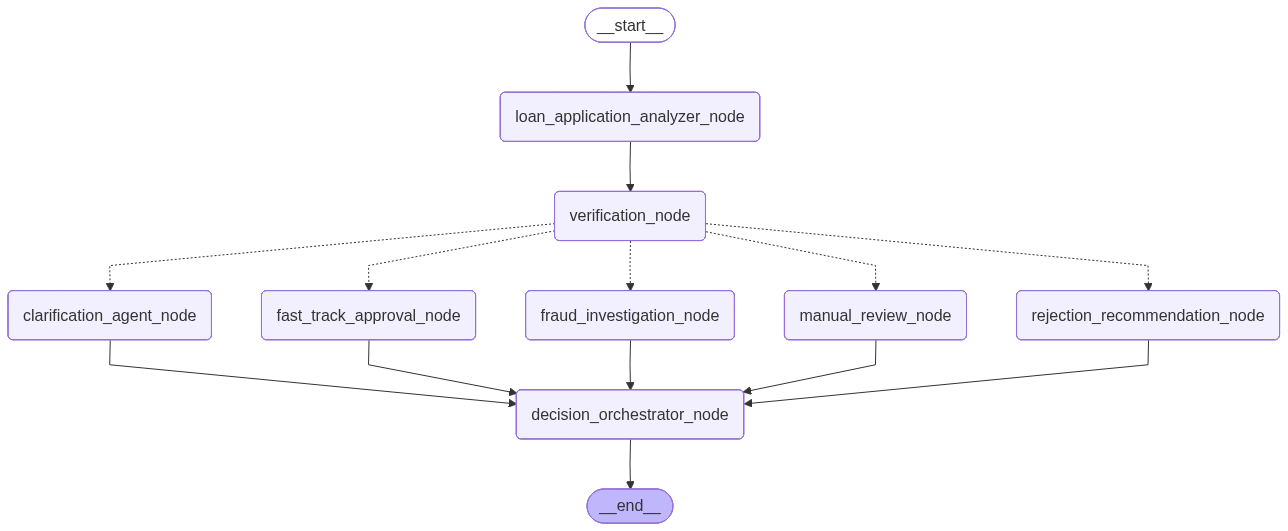

In [ ]:
from IPython.display import Image, display

try:
    print("Finance Workflow Graph:")
    graph_finance = finance_workflow.get_graph()
    # Get the PNG image data and display it
    png_data_finance = graph_finance.draw_mermaid_png()
    display(Image(png_data_finance))
except Exception as e:
    print(f"Could not draw graph: {e}")
    print("Please ensure the 'graphviz' system package is installed (e.g., sudo apt-get install graphviz) and required Python packages like pydot and graphviz are installed.")

### Example Invocation for Finance Workflow

Let's test the financial workflow with a sample query.

In [ ]:
import json

# Sample loan application data for Finance Workflow (Loan Risk Assessment)
sample_loan_application_good_credit = LoanApplicationInput(
    applicant_name="Alice Smith",
    loan_amount=50000.0,
    employment_type="employed",
    credit_score=750,
    has_salary_slips=True,
    has_bank_statements=True,
    query="I need a personal loan for home renovation."
)

sample_loan_application_high_risk = LoanApplicationInput(
    applicant_name="Charlie Brown",
    loan_amount=150000.0,
    employment_type="self-employed",
    credit_score=550,
    has_salary_slips=False,
    has_bank_statements=True,
    query="I want a business loan. My name is Charlie Suspect."
)

sample_loan_application_missing_docs = LoanApplicationInput(
    applicant_name="Bob Johnson",
    loan_amount=20000.0,
    employment_type="employed",
    credit_score=680,
    has_salary_slips=False,
    has_bank_statements=False,
    query="Need a quick loan."
)

In [ ]:
# Example Invocation: Good Credit Applicant

# Invoke the finance workflow with the pre-populated initial state
finance_response_good_credit = finance_workflow.invoke(
    {
        "query": sample_loan_application_good_credit.model_dump_json()
    }
)

print("\n--- Financial Workflow Output (Good Credit) ---")
print(finance_response_good_credit["output"])

[finance_route_decision] Credit Score: 750, Fraud Risk: 25, Missing Docs: [], DTI: 0.3, KYC: True, Employment: True

--- Financial Workflow Output (Good Credit) ---

  --- Loan Decision Summary for Alice Smith: ---
  Decision: FAST_TRACK
  Rationale: Applicant Alice Smith qualifies for fast-track approval due to excellent credit score (750) and low fraud risk (25).
  Risk Summary: Credit Score: 750. Fraud Risk Score: 25. DTI: 0.3%. Income Stability: high.
  Recommended Loan Amount: $50,000.00
  Suggested Interest Slab: A
  Applicant Notification: Congratulations Alice Smith! Your loan application for 50000.0$ has been fast-track approved with a competitive interest rate. We will contact you shortly to finalize the details.
  


In [ ]:
# Example Invocation: High Risk Applicant
finance_response_high_risk = finance_workflow.invoke(
    {
        "query": sample_loan_application_high_risk.model_dump_json()
    }
)

print("\n--- Financial Workflow Output (High Risk) ---")
print(finance_response_high_risk["output"])

[finance_route_decision] Credit Score: 550, Fraud Risk: 35, Missing Docs: ['Salary Slips'], DTI: 0.0, KYC: True, Employment: True

--- Financial Workflow Output (High Risk) ---

  --- Loan Decision Summary for Charlie Brown: ---
  Decision: CLARIFICATION_NEEDED
  Rationale: Loan application for Charlie Brown requires clarification due to missing documents: Salary Slips.
  Risk Summary: Credit Score: 550. Fraud Risk Score: 35. DTI: 0.0%. Income Stability: low. Missing Documents: Salary Slips.
  Recommended Loan Amount: $0.00
  Suggested Interest Slab: N/A
  Applicant Notification: Dear Charlie Brown, your loan application requires Salary Slips. Please provide these to proceed.
  


In [ ]:
# Example Invocation: Missing Documents Applicant
finance_response_missing_docs = finance_workflow.invoke(
    {
        "query": sample_loan_application_missing_docs.model_dump_json()
    }
)

print("\n--- Financial Workflow Output (Missing Docs) ---")
print(finance_response_missing_docs["output"])

[finance_route_decision] Credit Score: 680, Fraud Risk: 35, Missing Docs: ['Salary Slips', 'Bank Statements'], DTI: -1.0, KYC: True, Employment: True

--- Financial Workflow Output (Missing Docs) ---

  --- Loan Decision Summary for Bob Johnson: ---
  Decision: CLARIFICATION_NEEDED
  Rationale: Loan application for Bob Johnson requires clarification due to missing documents: Salary Slips, Bank Statements.
  Risk Summary: Credit Score: 680. Fraud Risk Score: 35. DTI: -1.0%. Income Stability: low. Missing Documents: Salary Slips, Bank Statements.
  Recommended Loan Amount: $0.00
  Suggested Interest Slab: N/A
  Applicant Notification: Dear Bob Johnson, your loan application requires Salary Slips, Bank Statements. Please provide these to proceed.
  
